# Module 6 - Financial Impact Dashboard
## MedCore Pharma | Demand Planning Intelligence

Objective: Consolidate forecast error, outlier, and bullwhip findings from
Modules 2-5 into a single financial impact view, quantifying excess inventory cost and stockout risk per SKU and per product family.

Methodology:
- Excess inventory cost = (avg stock_on_hand above optimal level) x unit_cost
- Stockout risk = weeks where stock_on_hand hits 0, valued at lost margin
- Consolidated at SKU level, then aggregated by family for executive summary

Stack: pandas, numpy, matplotlib, SQLite

In [1]:
# Cell 1 : Imports & Load All Tables 

import pandas as pd
import numpy as np
import sqlite3
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DB_PATH = os.path.join("..", "data", "medcore.db")
conn = sqlite3.connect(DB_PATH)

df_products    = pd.read_sql("SELECT * FROM product_master", conn)
df_demand      = pd.read_sql("SELECT * FROM demand_history", conn)
df_sku_perf    = pd.read_sql("SELECT * FROM sku_performance", conn)
df_bullwhip    = pd.read_sql("SELECT * FROM bullwhip_analysis", conn)

df_products = df_products.rename(columns={"SKU_ID": "sku_id"})

print("Tables loaded :")
print(f"  product_master   : {df_products.shape}")
print(f"  demand_history   : {df_demand.shape}")
print(f"  sku_performance  : {df_sku_perf.shape}")
print(f"  bullwhip_analysis: {df_bullwhip.shape}")

print("\nproduct_master columns   :", list(df_products.columns))
print("demand_history columns   :", list(df_demand.columns))
print("sku_performance columns  :", list(df_sku_perf.columns))

Tables loaded :
  product_master   : (50, 7)
  demand_history   : (7600, 6)
  sku_performance  : (50, 20)
  bullwhip_analysis: (50, 6)

product_master columns   : ['sku_id', 'Family', 'Market', 'Unit_Cost', 'has_bias', 'has_seasonality', 'has_bullwhip']
demand_history columns   : ['sku_id', 'week', 'actual_demand', 'stock_on_hand', 'outlier_type', 'week_number']
sku_performance columns  : ['sku_id', 'family', 'market', 'unit_cost', 'has_bias_flag', 'has_seasonality', 'has_bullwhip', 'avg_demand', 'mape', 'bias', 'total_weeks', 'excess_stock_units', 'excess_stock_eur', 'stockout_risk_units', 'stockout_risk_eur', 'mape_score', 'bias_score', 'financial_score', 'risk_score', 'risk_category']


In [2]:
# Cell 1ter : Inspect financial columns

financial_cols = ["sku_id", "family", "excess_stock_units", "excess_stock_eur",
                   "stockout_risk_units", "stockout_risk_eur", "financial_score", "risk_category"]

print(df_sku_perf[financial_cols].sort_values("excess_stock_eur", ascending=False).head(10).to_string(index=False))

print(f"\nTotal excess stock value (EUR) : {df_sku_perf['excess_stock_eur'].sum():,.0f}")
print(f"Total stockout risk value (EUR) : {df_sku_perf['stockout_risk_eur'].sum():,.0f}")
print(f"\nRisk category distribution :")
print(df_sku_perf['risk_category'].value_counts())

 sku_id               family  excess_stock_units  excess_stock_eur  stockout_risk_units  stockout_risk_eur  financial_score risk_category
SKU-049 Diagnostic Equipment                94.0          226300.0                  0.0                0.0         1.000000          HIGH
SKU-048 Diagnostic Equipment                91.0          217690.0                  0.0                0.0         0.961680          HIGH
SKU-013      Medical Devices               178.0          165166.0                  0.0                0.0         0.727917          HIGH
SKU-019      Medical Devices               195.0          159081.0                  0.0                0.0         0.700835          HIGH
SKU-005      Medical Devices               167.0          156644.0                  0.0                0.0         0.689989          HIGH
SKU-015      Medical Devices               202.0          153092.0                  0.0                0.0         0.674181          HIGH
SKU-042 Diagnostic Equipment      

In [3]:
# Cell 2 : Consolidate all modules into one financial view

df_model_comp = pd.read_sql("SELECT sku_id, mape_baseline, mape_hw, mape_xgb, best_model, best_mape FROM model_comparison", conn)

# Start from the financial base (sku_performance)
df_master = df_sku_perf[["sku_id", "family", "unit_cost", "avg_demand", "mape", "bias",
                          "excess_stock_units", "excess_stock_eur",
                          "stockout_risk_units", "stockout_risk_eur",
                          "financial_score", "risk_category",
                          "has_bias_flag", "has_seasonality", "has_bullwhip"]].copy()

# Add best forecast model (only exists for HIGH risk SKUs from Module 4 — left join keeps everyone)
df_master = df_master.merge(df_model_comp, on="sku_id", how="left")

# Add bullwhip ratio
df_master = df_master.merge(df_bullwhip[["sku_id", "bullwhip_ratio"]], on="sku_id", how="left")

# Total financial exposure = excess stock + stockout risk
df_master["total_exposure_eur"] = df_master["excess_stock_eur"] + df_master["stockout_risk_eur"]

print(f"Consolidated table : {df_master.shape}")
print(f"\nSKUs with a best_model assigned (from M4, HIGH risk only) : {df_master['best_model'].notna().sum()} / {len(df_master)}")
print(f"\nTotal financial exposure (EUR) : {df_master['total_exposure_eur'].sum():,.0f}")

print("\nTop 10 by total exposure :")
print(df_master.sort_values("total_exposure_eur", ascending=False)[
    ["sku_id", "family", "risk_category", "excess_stock_eur", "bullwhip_ratio", "best_model"]
].head(10).to_string(index=False))

Consolidated table : (50, 22)

SKUs with a best_model assigned (from M4, HIGH risk only) : 11 / 50

Total financial exposure (EUR) : 3,212,868

Top 10 by total exposure :
 sku_id               family risk_category  excess_stock_eur  bullwhip_ratio   best_model
SKU-049 Diagnostic Equipment          HIGH          226300.0        1.358677 Holt-Winters
SKU-048 Diagnostic Equipment          HIGH          217690.0        0.887167     Baseline
SKU-013      Medical Devices          HIGH          165166.0        1.533448 Holt-Winters
SKU-019      Medical Devices          HIGH          159081.0        0.690170 Holt-Winters
SKU-005      Medical Devices          HIGH          156644.0        1.388326 Holt-Winters
SKU-015      Medical Devices          HIGH          153092.0        1.041457 Holt-Winters
SKU-042 Diagnostic Equipment        MEDIUM          148785.0        1.175240          NaN
SKU-014      Medical Devices          HIGH          127957.0        1.332911 Holt-Winters
SKU-050 Diagnostic 

In [4]:
# Cell 3 : Family-level executive summary

family_summary = df_master.groupby("family").agg(
    n_skus              = ("sku_id", "count"),
    total_excess_eur    = ("excess_stock_eur", "sum"),
    total_stockout_eur  = ("stockout_risk_eur", "sum"),
    total_exposure_eur  = ("total_exposure_eur", "sum"),
    avg_mape            = ("mape", "mean"),
    avg_bullwhip_ratio  = ("bullwhip_ratio", "mean"),
    n_high_risk         = ("risk_category", lambda x: (x == "HIGH").sum())
).reset_index()

family_summary = family_summary.sort_values("total_exposure_eur", ascending=False)

# Share of total exposure
family_summary["share_of_total_pct"] = (
    family_summary["total_exposure_eur"] / family_summary["total_exposure_eur"].sum() * 100
).round(1)

print("=== Executive Summary by Family ===\n")
print(family_summary.to_string(index=False))

=== Executive Summary by Family ===

              family  n_skus  total_excess_eur  total_stockout_eur  total_exposure_eur  avg_mape  avg_bullwhip_ratio  n_high_risk  share_of_total_pct
     Medical Devices      20         1196992.0                 0.0           1196992.0     13.11            0.983360            5                37.3
Surgical Consumables      20         1058154.0                 0.0           1058154.0     15.88            1.151864            4                32.9
Diagnostic Equipment      10          957722.0                 0.0            957722.0     11.88            0.772096            2                29.8


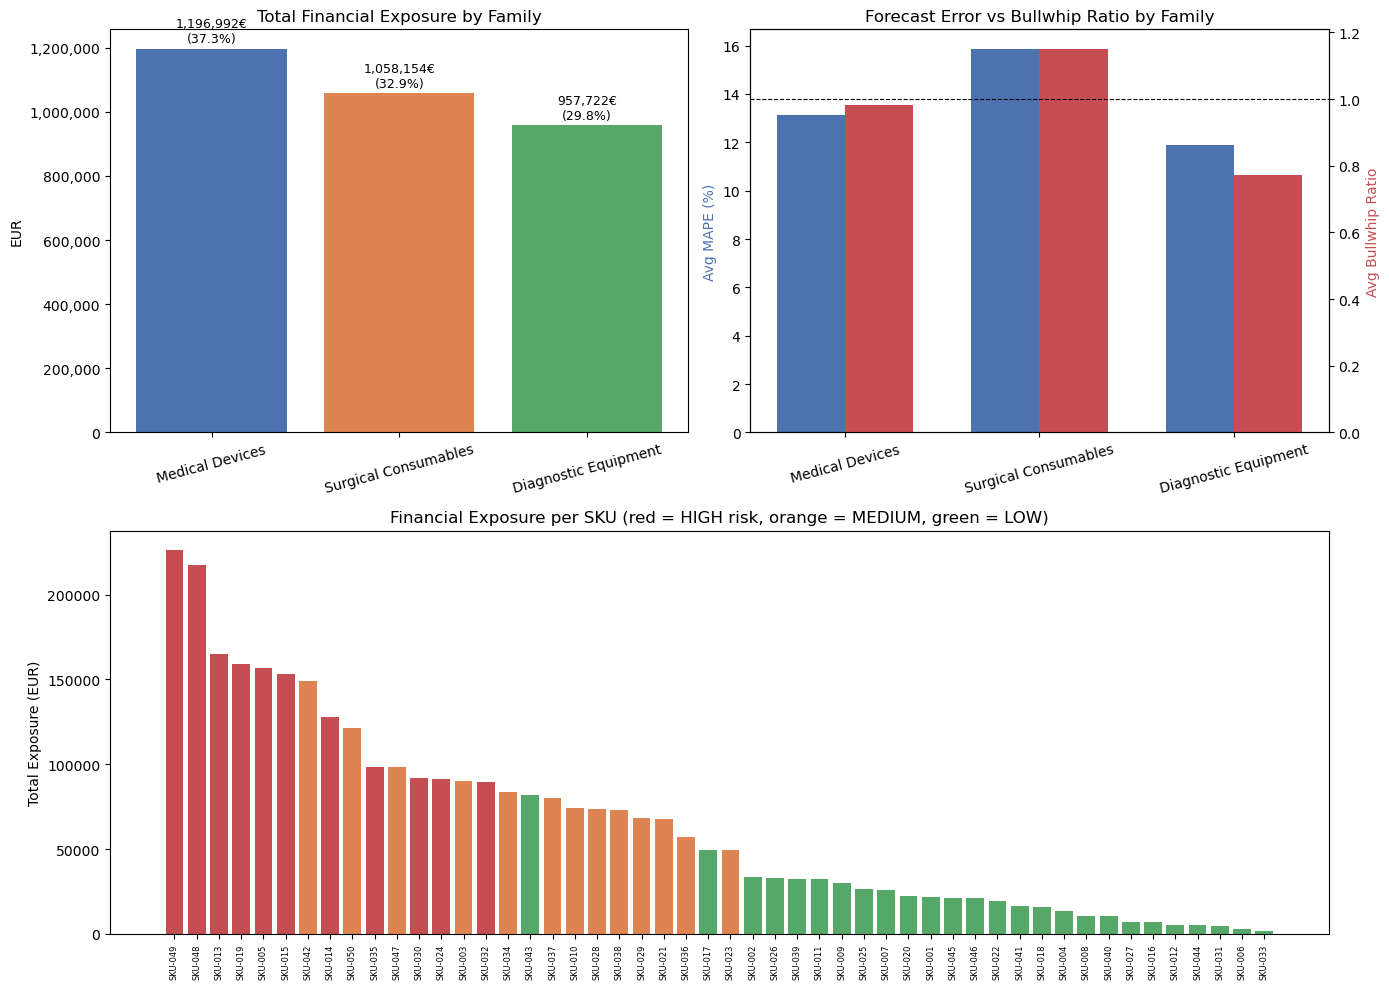

Chart saved to outputs/module6_financial_dashboard.png


In [5]:
# Cell 4 : Executive Visualization

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

colors = ["#4C72B0", "#DD8452", "#55A868"]

# Plot 1 : Total exposure by family
from matplotlib.ticker import FuncFormatter

ax1.bar(family_summary["family"], family_summary["total_exposure_eur"], color=colors)
ax1.set_title("Total Financial Exposure by Family")
ax1.set_ylabel("EUR")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
for i, (v, pct) in enumerate(zip(family_summary["total_exposure_eur"], family_summary["share_of_total_pct"])):
    ax1.text(i, v + 20000, f"{v:,.0f}€\n({pct}%)", ha="center", fontsize=9)
ax1.tick_params(axis='x', rotation=15)

# Plot 2 : Avg MAPE vs Avg Bullwhip ratio by family
x = np.arange(len(family_summary))
width = 0.35
ax2_twin = ax2.twinx()
ax2.bar(x - width/2, family_summary["avg_mape"], width, label="Avg MAPE (%)", color="#4C72B0")
ax2_twin.bar(x + width/2, family_summary["avg_bullwhip_ratio"], width, label="Avg Bullwhip Ratio", color="#C44E52")
ax2.set_xticks(x)
ax2.set_xticklabels(family_summary["family"], rotation=15)
ax2.set_ylabel("Avg MAPE (%)", color="#4C72B0")
ax2_twin.set_ylabel("Avg Bullwhip Ratio", color="#C44E52")
ax2_twin.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
ax2.set_title("Forecast Error vs Bullwhip Ratio by Family")

# Plot 3 : SKU-level exposure, colored by risk category
risk_colors = {"HIGH": "#C44E52", "MEDIUM": "#DD8452", "LOW": "#55A868"}
df_sorted = df_master.sort_values("total_exposure_eur", ascending=False)
bar_colors = [risk_colors[r] for r in df_sorted["risk_category"]]

x3 = np.arange(len(df_sorted))
ax3.bar(x3, df_sorted["total_exposure_eur"], color=bar_colors)
ax3.set_xticks(x3)
ax3.set_xticklabels(df_sorted["sku_id"], rotation=90, fontsize=6)
ax3.set_ylabel("Total Exposure (EUR)")
ax3.set_title("Financial Exposure per SKU (red = HIGH risk, orange = MEDIUM, green = LOW)")

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "module6_financial_dashboard.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved to outputs/module6_financial_dashboard.png")

In [6]:
# Cell 5 : Save to SQLite

df_master.to_sql("financial_impact", conn, if_exists="replace", index=False)
family_summary.to_sql("financial_summary_by_family", conn, if_exists="replace", index=False)

print(f"Table 'financial_impact' saved         : {len(df_master)} rows")
print(f"Table 'financial_summary_by_family' saved : {len(family_summary)} rows")

conn.close()
print("\nConnection closed.")

Table 'financial_impact' saved         : 50 rows
Table 'financial_summary_by_family' saved : 3 rows

Connection closed.


In [7]:
# --- Export tables for Power BI ---

import pandas as pd
import sqlite3
import os

DB_PATH = os.path.join("..", "data", "medcore.db")
conn = sqlite3.connect(DB_PATH)

EXPORT_DIR = os.path.join("..", "outputs", "powerbi")
os.makedirs(EXPORT_DIR, exist_ok=True)

tables_to_export = [
    "product_master",
    "sku_performance",
    "outlier_detection",
    "model_comparison",
    "bullwhip_analysis",
    "financial_impact",
    "financial_summary_by_family"
]

for table in tables_to_export:
    df = pd.read_sql(f"SELECT * FROM {table}", conn)
    csv_path = os.path.join(EXPORT_DIR, f"{table}.csv")
    df.to_csv(csv_path, index=False)
    print(f"{table:30s} -> {len(df)} rows exported")

conn.close()
print("\nAll tables exported to outputs/powerbi/")

product_master                 -> 50 rows exported
sku_performance                -> 50 rows exported
outlier_detection              -> 7600 rows exported
model_comparison               -> 11 rows exported
bullwhip_analysis              -> 50 rows exported
financial_impact               -> 50 rows exported
financial_summary_by_family    -> 3 rows exported

All tables exported to outputs/powerbi/
